# Lecture de OPEN_MEDIC_2025.CSV et analyse R06A


In [67]:
# Si besoin, installer les dependances dans ce notebook:
# %pip install pandas openpyxl

from pathlib import Path
import re
import pandas as pd
SOURCE_DIR = Path("sources/open_medic")
assert SOURCE_DIR.exists(), f"Dossier sources introuvable: {SOURCE_DIR}"


In [68]:
xlsx_path = SOURCE_DIR / "2025-01-a-06_medic-am-par-classe-atc_serie-mensuelle-labellisee.xlsx"
assert xlsx_path.exists(), f"Fichier introuvable: {xlsx_path}"

xls = pd.ExcelFile(xlsx_path)
print("Onglets disponibles:", xls.sheet_names)


Onglets disponibles: ['lisez-moi', '2025_atc1_total', '2025_atc1_100% et non à 100%', '2025_atc2_total', '2025_atc2_100% et non à 100%', '2025_atc3_total', '2025_atc3_100% et non à 100%', '2025_atc4_total', '2025_atc4_100% et non à 100%', '2025_atc5_total', '2025_atc5_100% et non à 100%', '2025_cip_total', '2025_cip13_100% et non à 100%']


## Analyse cible R06A (antihistaminiques systemiques)
Objectif: preparer une base comparable pour Paris (75), Marseille (13), Strasbourg (67), Bordeaux (33).


In [69]:
ville_to_dep = {
    "Paris": "75",
    "Marseille": "13",
    "Strasbourg": "67",
    "Bordeaux": "33",
}
target_deps = set(ville_to_dep.values())
atc_target = "R06A"

print("Villes cibles:", ville_to_dep)
print("Departements cibles:", sorted(target_deps))
print("Code ATC cible:", atc_target)


Villes cibles: {'Paris': '75', 'Marseille': '13', 'Strasbourg': '67', 'Bordeaux': '33'}
Departements cibles: ['13', '33', '67', '75']
Code ATC cible: R06A


In [70]:
sheet_name = "2025_atc3_total"
df_atc3 = pd.read_excel(xlsx_path, sheet_name=sheet_name, header=5)
df_atc3.columns = (
    df_atc3.columns.astype(str)
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

code_col = next(c for c in df_atc3.columns if c.lower().startswith("code atc3"))
lib_col = next(c for c in df_atc3.columns if ("atc3" in c.lower() and c != code_col))

print("Onglet charge:", sheet_name)
print("Shape:", df_atc3.shape)
print("Colonnes code/libelle:", code_col, "|", lib_col)
df_atc3.head(3)


Onglet charge: 2025_atc3_total
Shape: (195, 20)
Colonnes code/libelle: Code ATC3 | Libellé ATC3


,Code ATC3,Libellé ATC3,Base de remboursement 2025-01,Nombre de boites remboursées 2025-01,Montant remboursé 2025-01,Base de remboursement 2025-02,Nombre de boites remboursées 2025-02,Montant remboursé 2025-02,Base de remboursement 2025-03,Nombre de boites remboursées 2025-03,Montant remboursé 2025-03,Base de remboursement 2025-04,Nombre de boites remboursées 2025-04,Montant remboursé 2025-04,Base de remboursement 2025-05,Nombre de boites remboursées 2025-05,Montant remboursé 2025-05,Base de remboursement 2025-06,Nombre de boites remboursées 2025-06,Montant remboursé 2025-06
0,A01A,PREPARATIONS STOMATOLOGIQUES,3477610.02,1669549,7.890587e+05,3450707.06,1661195,7.602177e+05,3.546331e+06,1704443,7.881943e+05,3527141.10,1698906,7.757644e+05,3293437.72,1582821,7.360938e+05,3401448.57,1630579,7.642032e+05
1,A02A,ANTIACIDES,1210463.89,204584,7.286558e+05,1160898.71,187053,7.220425e+05,1.271980e+06,201133,8.017638e+05,1320701.83,199434,8.582169e+05,1295502.35,190616,8.549598e+05,1361156.05,191535,9.209230e+05
2,A02B,MEDICAMENTS POUR L'ULCÈRE PEPTIQUE ET LE REFLU...,31453312.41,8163356,2.241626e+07,28940064.69,7508152,2.038237e+07,3.023378e+07,7950869,2.133229e+07,30943606.37,8135631,2.188494e+07,29335312.13,7718741,2.077666e+07,29843675.88,7853514,2.116037e+07


In [71]:
import re


In [72]:
monthly_cols = [c for c in df_atc3.columns if re.search(r"20\d{2}-\d{2}$", c)]
months = sorted({re.search(r"(20\d{2}-\d{2})$", c).group(1) for c in monthly_cols})
metrics = sorted({re.sub(r"\s*20\d{2}-\d{2}$", "", c).strip() for c in monthly_cols})

print("Aggregation temporelle actuelle:")
print("- granularite: mensuelle")
print("- fenetre: ", months[0], "a", months[-1])
print("- nb mois: ", len(months))
print("- indicateurs mensuels: ", metrics)


Aggregation temporelle actuelle:
- granularite: mensuelle
- fenetre:  2025-01 a 2025-06
- nb mois:  6
- indicateurs mensuels:  ['Base de remboursement', 'Montant remboursé', 'Nombre de boites remboursées']


In [73]:
df_r06a = df_atc3.loc[df_atc3[code_col].eq(atc_target)].copy()
assert not df_r06a.empty, "R06A introuvable dans cet onglet"

value_cols = [c for c in df_r06a.columns if re.search(r"20\d{2}-\d{2}$", c)]
df_r06a_long = df_r06a.melt(
    id_vars=[code_col, lib_col],
    value_vars=value_cols,
    var_name="variable_mois",
    value_name="valeur",
)
df_r06a_long["mois"] = df_r06a_long["variable_mois"].str.extract(r"(20\d{2}-\d{2})$")
df_r06a_long["indicateur"] = (
    df_r06a_long["variable_mois"]
    .str.replace(r"\s*20\d{2}-\d{2}$", "", regex=True)
    .str.strip()
)
df_r06a_long = df_r06a_long[[code_col, lib_col, "mois", "indicateur", "valeur"]]
df_r06a_long = df_r06a_long.sort_values(["mois", "indicateur"]).reset_index(drop=True)

print("R06A detecte:", df_r06a.iloc[0][lib_col])
df_r06a_long.head(12)


R06A detecte: ANTIHISTAMINIQUES A USAGE SYSTEMIQUE


,Code ATC3,Libellé ATC3,mois,indicateur,valeur
0,R06A,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,2025-01,Base de remboursement,1.165664e+07
1,R06A,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,2025-01,Montant remboursé,4.234011e+06
2,R06A,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,2025-01,Nombre de boites remboursées,4.065407e+06
3,R06A,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,2025-02,Base de remboursement,1.085763e+07
4,R06A,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,2025-02,Montant remboursé,3.950060e+06
5,R06A,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,2025-02,Nombre de boites remboursées,3.753860e+06
6,R06A,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,2025-03,Base de remboursement,1.299239e+07
7,R06A,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,2025-03,Montant remboursé,4.739326e+06
8,R06A,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,2025-03,Nombre de boites remboursées,4.376486e+06
9,R06A,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,2025-04,Base de remboursement,1.612774e+07


In [74]:
# Etape 3 (taux pour 1000 habitants) - pre-requis population departementale
# BEN_REG est un code region: on mappe les departements 13/33/67/75 vers leurs regions.
pop_dep = pd.Series(
    {"13": 2087658, "33": 1690493, "67": 1163810, "75": 2103778},
    name="population",
).rename_axis("dep").reset_index()

dep_to_ben_reg = {
    "13": "93",  # Provence-Alpes-Cote d'Azur
    "33": "75",  # Nouvelle-Aquitaine
    "67": "44",  # Grand Est
    "75": "11",  # Ile-de-France
}
pop_dep["BEN_REG"] = pop_dep["dep"].map(dep_to_ben_reg)
display(pop_dep.sort_values("dep").reset_index(drop=True))

if "df" in locals() and {"BEN_REG", "ATC3", "BOITES", "REM"}.issubset(df.columns):
    target_ben_reg = sorted(pop_dep["BEN_REG"].dropna().unique().tolist())
    df["BEN_REG_STR"] = df["BEN_REG"].astype(str).str.strip().str.zfill(2)
    df_scope = df.loc[df["BEN_REG_STR"].isin(target_ben_reg)].copy()

    print("Codes BEN_REG cibles:", target_ben_reg)
    print("Shape filtree (BEN_REG):", df_scope.shape)
    print("BEN_REG presents apres filtre:", sorted(df_scope["BEN_REG_STR"].unique()))

    resume_ben_reg = (
        df_scope.groupby("BEN_REG_STR", as_index=False)
        .agg(nb_lignes=("ATC3", "size"), boites=("BOITES", "sum"), rem=("REM", "sum"))
        .sort_values("BEN_REG_STR")
    )
    resume_ben_reg = resume_ben_reg.merge(
        pop_dep[["dep", "population", "BEN_REG"]],
        left_on="BEN_REG_STR",
        right_on="BEN_REG",
        how="left",
    )
    resume_ben_reg["boites_pour_1000_hab"] = resume_ben_reg["boites"] / resume_ben_reg["population"] * 1000
    display(resume_ben_reg[["dep", "BEN_REG_STR", "population", "nb_lignes", "boites", "rem", "boites_pour_1000_hab"]])
else:
    print("INFO: la base OPEN_MEDIC detaillee (df) n est pas chargee dans ce notebook.")
    print("Le mapping dep->BEN_REG est conserve et sera reutilise plus bas pour la cible mensuelle.")

print("Note: avec BEN_REG, les volumes sont regionaux (pas strictement departementaux).")


,dep,population,BEN_REG
0,13,2087658,93
1,33,1690493,75
2,67,1163810,44
3,75,2103778,11


Codes BEN_REG cibles: ['11', '44', '75', '93']
Shape filtree (BEN_REG): (840304, 22)
BEN_REG presents apres filtre: ['11', '44', '75', '93']


,dep,BEN_REG_STR,population,nb_lignes,boites,rem,boites_pour_1000_hab
0,75,11,2103778,266765,351702061,"3,9915,040,7571,93221,84169,71132,4777,67213,8...",167176.413576
1,67,44,1163810,176603,188689824,"4,77100,0235,11133,0089,3847,883.289,89988,462...",162131.124496
2,33,75,1690493,187256,211773056,"74,4860,6529,793.326,061.136,35291,54596,382.8...",125272.956469
3,13,93,2087658,209680,204509715,"40,3778,2071,2984,0663,841.776,88404,36583,072...",97961.311192


Note: avec BEN_REG, les volumes sont regionaux (pas strictement departementaux).


In [75]:
# Etape 4 - Inventaire des fichiers OPEN MEDIC (xlsx) et controle de completude annuelle
import re
from pathlib import Path

exclude_file = "2024_descriptif-variables_open-medic.xls"
pattern = re.compile(
    r"^(?P<annee>\d{4})-(?P<semestre>01-a-06|07-a-12)_medic-am-par-classe-atc_serie-mensuelle(?:-labellisee)?\.(?P<ext>xlsx|zip)$"
)

catalog = []
for p in sorted(SOURCE_DIR.iterdir()):
    if not p.is_file() or p.name == exclude_file:
        continue
    m = pattern.match(p.name)
    if not m:
        continue
    catalog.append({
        "fichier": p.name,
        "annee": int(m.group("annee")),
        "semestre": m.group("semestre"),
        "ext": m.group("ext"),
        "path": str(p),
    })

inventory_df = pd.DataFrame(catalog).sort_values(["annee", "semestre", "ext", "fichier"]).reset_index(drop=True)
display(inventory_df)

expected_semesters = {"01-a-06", "07-a-12"}
years = sorted(inventory_df["annee"].unique().tolist()) if not inventory_df.empty else []

alerts = []
for annee in years:
    y = inventory_df.loc[inventory_df["annee"].eq(annee)]
    xlsx_sem = set(y.loc[y["ext"].eq("xlsx"), "semestre"].tolist())
    zip_sem = set(y.loc[y["ext"].eq("zip"), "semestre"].tolist())
    missing_xlsx = sorted(expected_semesters - xlsx_sem)
    if missing_xlsx:
        alerts.append(
            f"Annee {annee}: xlsx manquant(s) pour {missing_xlsx}. Semestres zip presents: {sorted(zip_sem) if zip_sem else []}"
        )

if alerts:
    print("ALERTE COMPLETUDE (xlsx):")
    for msg in alerts:
        print("-", msg)
else:
    print("OK: chaque annee detectee dispose des 2 fichiers xlsx (01-a-06 et 07-a-12).")


,fichier,annee,semestre,ext,path
0,2022-01-a-06_medic-am-par-classe-atc_serie-men...,2022,01-a-06,xlsx,2022-01-a-06_medic-am-par-classe-atc_serie-men...
1,2022-07-a-12_medic-am-par-classe-atc_serie-men...,2022,07-a-12,xlsx,2022-07-a-12_medic-am-par-classe-atc_serie-men...
2,2023-01-a-06_medic-am-par-classe-atc_serie-men...,2023,01-a-06,xlsx,2023-01-a-06_medic-am-par-classe-atc_serie-men...
3,2023-07-a-12_medic-am-par-classe-atc_serie-men...,2023,07-a-12,xlsx,2023-07-a-12_medic-am-par-classe-atc_serie-men...
4,2024-01-a-06_medic-am-par-classe-atc_serie-men...,2024,01-a-06,xlsx,2024-01-a-06_medic-am-par-classe-atc_serie-men...
5,2024-07-a-12_medic-am-par-classe-atc_serie-men...,2024,07-a-12,xlsx,2024-07-a-12_medic-am-par-classe-atc_serie-men...
6,2025-01-a-06_medic-am-par-classe-atc_serie-men...,2025,01-a-06,xlsx,2025-01-a-06_medic-am-par-classe-atc_serie-men...
7,2025-07-a-12_medic-am-par-classe-atc_serie-men...,2025,07-a-12,xlsx,2025-07-a-12_medic-am-par-classe-atc_serie-men...


OK: chaque annee detectee dispose des 2 fichiers xlsx (01-a-06 et 07-a-12).


In [76]:
# Etape 5 - Chargement de tous les xlsx et mise au format long mensuel
def _clean_columns(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()
    df.columns = (
        df.columns.astype(str)
        .str.replace("\n", " ", regex=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    return df

def _pick_atc3_sheet(xls: pd.ExcelFile, annee: int) -> str:
    exact = f"{annee}_atc3_total"
    if exact in xls.sheet_names:
        return exact
    candidates = [s for s in xls.sheet_names if "atc3_total" in s.lower()]
    if len(candidates) == 1:
        return candidates[0]
    year_candidates = [s for s in candidates if str(annee) in s]
    if len(year_candidates) == 1:
        return year_candidates[0]
    raise ValueError(f"Impossible de choisir un onglet atc3_total pour {annee}. Onglets: {xls.sheet_names}")

xlsx_inventory = inventory_df.loc[inventory_df["ext"].eq("xlsx")].copy()
frames = []
load_errors = []

for _, row in xlsx_inventory.iterrows():
    annee = int(row["annee"])
    semestre = row["semestre"]
    file_path = Path(row["path"])
    try:
        xls = pd.ExcelFile(file_path)
        sheet_name = _pick_atc3_sheet(xls, annee)
        df_atc3 = pd.read_excel(file_path, sheet_name=sheet_name, header=5)
        df_atc3 = _clean_columns(df_atc3)

        code_col = next(c for c in df_atc3.columns if c.lower().startswith("code atc3"))
        lib_col = next(c for c in df_atc3.columns if ("atc3" in c.lower() and c != code_col))
        value_cols = [c for c in df_atc3.columns if re.search(r"20\d{2}-\d{2}$", c)]

        df_long = df_atc3.melt(
            id_vars=[code_col, lib_col],
            value_vars=value_cols,
            var_name="variable_mois",
            value_name="valeur",
        )
        df_long["mois"] = df_long["variable_mois"].str.extract(r"(20\d{2}-\d{2})$")
        df_long["indicateur"] = (
            df_long["variable_mois"]
            .str.replace(r"\s*20\d{2}-\d{2}$", "", regex=True)
            .str.strip()
        )
        df_long = df_long.rename(columns={code_col: "code_atc3", lib_col: "libelle_atc3"})
        df_long["annee"] = annee
        df_long["semestre"] = semestre
        df_long["fichier_source"] = file_path.name
        df_long = df_long[[
            "annee", "semestre", "mois", "code_atc3", "libelle_atc3",
            "indicateur", "valeur", "fichier_source"
        ]]
        frames.append(df_long)
    except Exception as e:
        load_errors.append({
            "fichier": file_path.name,
            "annee": annee,
            "semestre": semestre,
            "erreur": str(e),
        })

if load_errors:
    print("ERREURS DE CHARGEMENT:")
    display(pd.DataFrame(load_errors))

if frames:
    df_atc3_all = pd.concat(frames, ignore_index=True)
    df_atc3_all = df_atc3_all.sort_values(["mois", "code_atc3", "indicateur"]).reset_index(drop=True)
    print("Dataset fusionne cree: df_atc3_all")
    print("Shape:", df_atc3_all.shape)
    print("Periode:", df_atc3_all["mois"].min(), "a", df_atc3_all["mois"].max())
    display(df_atc3_all.head(10))
else:
    print("Aucun xlsx charge. Verifie l inventaire et les erreurs ci-dessus.")


Dataset fusionne cree: df_atc3_all
Shape: (28332, 8)
Periode: 2022-01 a 2025-12


,annee,semestre,mois,code_atc3,libelle_atc3,indicateur,valeur,fichier_source
0,2022,01-a-06,2022-01,A01A,PREPARATIONS STOMATOLOGIQUES,Base de remboursement,3.697515e+06,2022-01-a-06_medic-am-par-classe-atc_serie-men...
1,2022,01-a-06,2022-01,A01A,PREPARATIONS STOMATOLOGIQUES,Montant remboursé,9.446184e+05,2022-01-a-06_medic-am-par-classe-atc_serie-men...
2,2022,01-a-06,2022-01,A01A,PREPARATIONS STOMATOLOGIQUES,Nombre de boites remboursées,1.695785e+06,2022-01-a-06_medic-am-par-classe-atc_serie-men...
3,2022,01-a-06,2022-01,A02A,ANTIACIDES,Base de remboursement,7.311653e+05,2022-01-a-06_medic-am-par-classe-atc_serie-men...
4,2022,01-a-06,2022-01,A02A,ANTIACIDES,Montant remboursé,1.866165e+05,2022-01-a-06_medic-am-par-classe-atc_serie-men...
5,2022,01-a-06,2022-01,A02A,ANTIACIDES,Nombre de boites remboursées,2.200250e+05,2022-01-a-06_medic-am-par-classe-atc_serie-men...
6,2022,01-a-06,2022-01,A02B,MEDICAMENTS POUR L'ULCÈRE PEPTIQUE ET LE REFLU...,Base de remboursement,3.305566e+07,2022-01-a-06_medic-am-par-classe-atc_serie-men...
7,2022,01-a-06,2022-01,A02B,MEDICAMENTS POUR L'ULCÈRE PEPTIQUE ET LE REFLU...,Montant remboursé,2.429341e+07,2022-01-a-06_medic-am-par-classe-atc_serie-men...
8,2022,01-a-06,2022-01,A02B,MEDICAMENTS POUR L'ULCÈRE PEPTIQUE ET LE REFLU...,Nombre de boites remboursées,7.772728e+06,2022-01-a-06_medic-am-par-classe-atc_serie-men...
9,2022,01-a-06,2022-01,A03A,MEDICAMENTS POUR LES TROUBLES FONCTIONNELS INT...,Base de remboursement,8.265522e+06,2022-01-a-06_medic-am-par-classe-atc_serie-men...


In [77]:
# Etape 6 - Merge final et notification de completude par annee
if "df_atc3_all" not in locals():
    raise ValueError("df_atc3_all est absent. Execute l Etape 5 avant cette cellule.")

expected_by_sem = {"01-a-06": {f"{m:02d}" for m in range(1, 7)}, "07-a-12": {f"{m:02d}" for m in range(7, 13)}}
check_rows = []

for annee in sorted(inventory_df["annee"].unique().tolist()):
    y = inventory_df.loc[inventory_df["annee"].eq(annee)]
    xlsx_sem = sorted(y.loc[y["ext"].eq("xlsx"), "semestre"].unique().tolist())
    expected_months = sorted({m for sem in xlsx_sem for m in expected_by_sem.get(sem, set())})

    observed_months = sorted(
        df_atc3_all.loc[df_atc3_all["annee"].eq(annee), "mois"]
        .dropna()
        .str[-2:]
        .unique()
        .tolist()
    )
    missing_months = sorted(set(expected_months) - set(observed_months))
    missing_sem_xlsx = sorted(set(["01-a-06", "07-a-12"]) - set(xlsx_sem))

    check_rows.append({
        "annee": annee,
        "xlsx_semestres_presents": ", ".join(xlsx_sem) if xlsx_sem else "",
        "xlsx_semestres_manquants": ", ".join(missing_sem_xlsx) if missing_sem_xlsx else "",
        "mois_observes": ", ".join(observed_months),
        "mois_attendus_depuis_xlsx": ", ".join(expected_months),
        "mois_manquants_dans_merge": ", ".join(missing_months) if missing_months else "",
        "status": "OK" if not missing_sem_xlsx and not missing_months else "ALERTE",
    })

check_df = pd.DataFrame(check_rows).sort_values("annee").reset_index(drop=True)
display(check_df)

alerts = check_df.loc[check_df["status"].eq("ALERTE")]
if alerts.empty:
    print("OK: merge complet et 2 fichiers xlsx presents pour chaque annee detectee.")
else:
    print("ALERTE: des semestres ou des mois manquent. Voir check_df ci-dessus.")


,annee,xlsx_semestres_presents,xlsx_semestres_manquants,mois_observes,mois_attendus_depuis_xlsx,mois_manquants_dans_merge,status
0,2022,"01-a-06, 07-a-12",,"01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12","01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12",,OK
1,2023,"01-a-06, 07-a-12",,"01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12","01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12",,OK
2,2024,"01-a-06, 07-a-12",,"01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12","01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12",,OK
3,2025,"01-a-06, 07-a-12",,"01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12","01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12",,OK


OK: merge complet et 2 fichiers xlsx presents pour chaque annee detectee.


In [78]:
# Etape 2 — Passer du daily au mensuel (Option A) pour un merge compatible avec Ameli
pollen_daily_path = Path("Data/processed/pollen_weather_merged.csv")
hpi_daily_path = Path("Data/processed/hpi_daily.csv")
assert pollen_daily_path.exists(), f"Fichier introuvable: {pollen_daily_path}"
assert hpi_daily_path.exists(), f"Fichier introuvable: {hpi_daily_path}"

df_pollen_daily = pd.read_csv(pollen_daily_path, parse_dates=["date"])
df_hpi_daily = pd.read_csv(hpi_daily_path, parse_dates=["date"])

pollen_species_cols = [
    "birch_pollen", "alder_pollen", "grass_pollen",
    "olive_pollen", "mugwort_pollen", "ragweed_pollen",
]
missing_cols = [c for c in pollen_species_cols if c not in df_pollen_daily.columns]
assert not missing_cols, f"Colonnes pollen manquantes: {missing_cols}"
assert "HPI" in df_hpi_daily.columns, "Colonne HPI absente de hpi_daily.csv"

df_pollen_daily["pollen_total"] = df_pollen_daily[pollen_species_cols].sum(axis=1, min_count=1)
df_daily_city = df_pollen_daily[["date", "city", "pollen_total"]].merge(
    df_hpi_daily[["date", "city", "HPI"]],
    on=["date", "city"],
    how="inner",
    validate="one_to_one",
)
df_daily_city["mois"] = df_daily_city["date"].dt.to_period("M").astype(str)

df_city_monthly = (
    df_daily_city.groupby(["city", "mois"], as_index=False)
    .agg(
        pollen_moyen=("pollen_total", "mean"),
        hpi_moyen=("HPI", "mean"),
        nb_jours=("date", "nunique"),
    )
    .sort_values(["city", "mois"])
    .reset_index(drop=True)
)

print("Base mensuelle city-level (pollen + HPI):", df_city_monthly.shape)
print("Periode:", df_city_monthly["mois"].min(), "a", df_city_monthly["mois"].max())
display(df_city_monthly.head(12))


Base mensuelle city-level (pollen + HPI): (144, 5)
Periode: 2022-01 a 2024-12


,city,mois,pollen_moyen,hpi_moyen,nb_jours
0,Bordeaux,2022-01,0.000000,0.073758,31
1,Bordeaux,2022-02,0.195536,0.114608,28
2,Bordeaux,2022-03,21.625467,0.148539,31
3,Bordeaux,2022-04,9.199444,0.155461,30
4,Bordeaux,2022-05,34.702688,0.204953,31
5,Bordeaux,2022-06,23.311528,0.219908,30
6,Bordeaux,2022-07,21.060349,0.262222,31
7,Bordeaux,2022-08,8.336828,0.273336,31
8,Bordeaux,2022-09,2.800833,0.187068,30
9,Bordeaux,2022-10,0.070769,0.147939,31


In [79]:
# Etape 3 — Construire la variable cible (taux de remboursement pour 1000 habitants)
import unicodedata

if "df_atc3_all" not in locals():
    raise ValueError("df_atc3_all est absent. Execute d abord les cellules Etape 4-5-6 de la partie Ameli.")

city_to_dep = {
    "Paris": "75",
    "Marseille": "13",
    "Strasbourg": "67",
    "Bordeaux": "33",
}
dep_to_ben_reg = {"13": "93", "33": "75", "67": "44", "75": "11"}
dep_population = {"13": 2087658, "33": 1690493, "67": 1163810, "75": 2103778}

city_meta = (
    pd.DataFrame({"city": list(city_to_dep.keys()), "dep": list(city_to_dep.values())})
    .assign(
        BEN_REG=lambda d: d["dep"].map(dep_to_ben_reg),
        population=lambda d: d["dep"].map(dep_population),
    )
)

def _txt_norm(x: str) -> str:
    s = unicodedata.normalize("NFKD", str(x)).encode("ascii", "ignore").decode("ascii")
    return re.sub(r"\s+", " ", s).strip().lower()

df_r06a = df_atc3_all.loc[df_atc3_all["code_atc3"].eq("R06A")].copy()
if df_r06a.empty:
    raise ValueError("R06A absent de df_atc3_all")

ind_candidates = [
    ind for ind in df_r06a["indicateur"].dropna().unique().tolist()
    if ("boite" in _txt_norm(ind)) and ("rembours" in _txt_norm(ind))
]
if not ind_candidates:
    raise ValueError("Indicateur boites remboursées introuvable pour R06A")

target_indicator = sorted(ind_candidates)[0]
print("Indicateur cible retenu:", target_indicator)

df_target_fr = (
    df_r06a.loc[df_r06a["indicateur"].eq(target_indicator), ["mois", "valeur"]]
    .assign(boites_r06a_fr=lambda d: pd.to_numeric(d["valeur"], errors="coerce"))
    [["mois", "boites_r06a_fr"]]
    .dropna(subset=["boites_r06a_fr"])
    .groupby("mois", as_index=False)["boites_r06a_fr"].sum()
    .sort_values("mois")
    .reset_index(drop=True)
)

# Allocation ville basée uniquement sur la population des 4 départements.
city_weights = city_meta.copy()
city_weights["poids_alloc"] = city_weights["population"] / city_weights["population"].sum()
allocation_mode = "poids populationnels (base: df_atc3_all + populations dep)"

print("Mode d allocation:", allocation_mode)
display(city_weights)

df_target_city = city_weights.assign(_k=1).merge(df_target_fr.assign(_k=1), on="_k").drop(columns="_k")
df_target_city["boites_r06a_city_est"] = df_target_city["boites_r06a_fr"] * df_target_city["poids_alloc"]
df_target_city["remboursement_p1000"] = df_target_city["boites_r06a_city_est"] / df_target_city["population"] * 1000

df_model_monthly = df_city_monthly.merge(
    df_target_city[["city", "mois", "dep", "BEN_REG", "population", "boites_r06a_city_est", "remboursement_p1000"]],
    on=["city", "mois"],
    how="inner",
)
df_model_monthly = df_model_monthly.sort_values(["city", "mois"]).reset_index(drop=True)

print("Base modele mensuelle creee:", df_model_monthly.shape)
print("Periode commune pollen/HPI/Ameli:", df_model_monthly["mois"].min(), "a", df_model_monthly["mois"].max())
display(df_model_monthly.head(12))


Indicateur cible retenu: Nombre de boites remboursées
Mode d allocation: poids populationnels (base: df_atc3_all + populations dep)


,city,dep,BEN_REG,population,poids_alloc
0,Paris,75,11,2103778,0.298589
1,Marseille,13,93,2087658,0.296301
2,Strasbourg,67,44,1163810,0.165179
3,Bordeaux,33,75,1690493,0.239931


Base modele mensuelle creee: (144, 10)
Periode commune pollen/HPI/Ameli: 2022-01 a 2024-12


,city,mois,pollen_moyen,hpi_moyen,nb_jours,dep,BEN_REG,population,boites_r06a_city_est,remboursement_p1000
0,Bordeaux,2022-01,0.000000,0.073758,31,33,75,1690493,7.758352e+05,458.940219
1,Bordeaux,2022-02,0.195536,0.114608,28,33,75,1690493,7.711830e+05,456.188201
2,Bordeaux,2022-03,21.625467,0.148539,31,33,75,1690493,1.060663e+06,627.428152
3,Bordeaux,2022-04,9.199444,0.155461,30,33,75,1690493,1.093991e+06,647.142904
4,Bordeaux,2022-05,34.702688,0.204953,31,33,75,1690493,1.283983e+06,759.531825
5,Bordeaux,2022-06,23.311528,0.219908,30,33,75,1690493,1.212369e+06,717.168774
6,Bordeaux,2022-07,21.060349,0.262222,31,33,75,1690493,9.981457e+05,590.446510
7,Bordeaux,2022-08,8.336828,0.273336,31,33,75,1690493,8.798867e+05,520.491179
8,Bordeaux,2022-09,2.800833,0.187068,30,33,75,1690493,8.975399e+05,530.933803
9,Bordeaux,2022-10,0.070769,0.147939,31,33,75,1690493,8.805803e+05,520.901498


In [80]:
# Etape 4 — Test central: Modele A (Pollen) vs Modele B (Pollen + HPI)
import statsmodels.api as sm

if "df_model_monthly" not in locals():
    raise ValueError("df_model_monthly est absent. Execute d abord Etape 2 et Etape 3.")

df_global = (
    df_model_monthly.groupby("mois", as_index=False)
    .agg(
        remboursement_p1000=("remboursement_p1000", "mean"),
        pollen_moyen=("pollen_moyen", "mean"),
        hpi_moyen=("hpi_moyen", "mean"),
        n_villes=("city", "nunique"),
    )
    .dropna()
)

X_a = sm.add_constant(df_global[["pollen_moyen"]], has_constant="add")
X_b = sm.add_constant(df_global[["pollen_moyen", "hpi_moyen"]], has_constant="add")
y = df_global["remboursement_p1000"]

model_a = sm.OLS(y, X_a).fit()
model_b = sm.OLS(y, X_b).fit()
f_stat, p_val, df_diff = model_b.compare_f_test(model_a)

comparison_global = pd.DataFrame([
    {"modele": "A (pollen)", "R2": model_a.rsquared, "R2_adj": model_a.rsquared_adj, "AIC": model_a.aic, "BIC": model_a.bic},
    {"modele": "B (pollen + HPI)", "R2": model_b.rsquared, "R2_adj": model_b.rsquared_adj, "AIC": model_b.aic, "BIC": model_b.bic},
])
comparison_global["delta_R2_vs_A"] = comparison_global["R2"] - comparison_global.loc[0, "R2"]
display(comparison_global)

print("Nested F-test (B vs A):")
print(f"- F = {f_stat:.4f}")
print(f"- p-value = {p_val:.6f}")
print(f"- ddl diff = {int(df_diff)}")
print("Interpretation: p < 0.05 suggere que l ajout de HPI ameliore significativement le modele.")


,modele,R2,R2_adj,AIC,BIC,delta_R2_vs_A
0,A (pollen),0.543260,0.529826,403.981366,407.148404,0.000000
1,B (pollen + HPI),0.545782,0.518254,405.782000,410.532556,0.002522


Nested F-test (B vs A):
- F = 0.1833
- p-value = 0.671368
- ddl diff = 1
Interpretation: p < 0.05 suggere que l ajout de HPI ameliore significativement le modele.


In [81]:
# Etape 5 — Comparer le gain du modele B par ville
if "df_model_monthly" not in locals():
    raise ValueError("df_model_monthly est absent. Execute d abord Etape 2 et Etape 3.")

rows = []
for city, g in df_model_monthly.groupby("city"):
    g = g.dropna(subset=["remboursement_p1000", "pollen_moyen", "hpi_moyen"]).copy()
    if g.shape[0] < 8:
        rows.append({
            "city": city,
            "n_obs": g.shape[0],
            "R2_A": float("nan"),
            "R2_B": float("nan"),
            "delta_R2": float("nan"),
            "p_value_Ftest": float("nan"),
            "status": "trop peu d observations",
        })
        continue

    X_a = sm.add_constant(g[["pollen_moyen"]], has_constant="add")
    X_b = sm.add_constant(g[["pollen_moyen", "hpi_moyen"]], has_constant="add")
    y = g["remboursement_p1000"]

    m_a = sm.OLS(y, X_a).fit()
    m_b = sm.OLS(y, X_b).fit()
    f_stat, p_val, df_diff = m_b.compare_f_test(m_a)

    rows.append({
        "city": city,
        "n_obs": int(g.shape[0]),
        "R2_A": m_a.rsquared,
        "R2_B": m_b.rsquared,
        "R2_adj_A": m_a.rsquared_adj,
        "R2_adj_B": m_b.rsquared_adj,
        "delta_R2": m_b.rsquared - m_a.rsquared,
        "F_stat": f_stat,
        "p_value_Ftest": p_val,
        "status": "OK",
    })

city_model_comparison = pd.DataFrame(rows).sort_values("delta_R2", ascending=False).reset_index(drop=True)
display(city_model_comparison)

if "allocation_mode" in locals():
    print("Note allocation:", allocation_mode)
    print("Pour une inference forte par ville, il faut idealement des remboursements mensuels territoriaux observes (region/departement).")


,city,n_obs,R2_A,R2_B,R2_adj_A,R2_adj_B,delta_R2,F_stat,p_value_Ftest,status
0,Strasbourg,36,0.485643,0.538902,0.470515,0.510957,0.053259,3.811692,0.059423,OK
1,Paris,36,0.316522,0.361895,0.296420,0.323222,0.045373,2.346507,0.135096,OK
2,Bordeaux,36,0.526703,0.532432,0.512782,0.504095,0.005729,0.404376,0.529224,OK
3,Marseille,36,0.431610,0.434086,0.414892,0.399788,0.002476,0.144383,0.706397,OK


Note allocation: poids populationnels (base: df_atc3_all + populations dep)
Pour une inference forte par ville, il faut idealement des remboursements mensuels territoriaux observes (region/departement).


In [82]:
# Etape 7 — Etendre le dataset Ameli mensuel avec les fichiers 2014
def _infer_year_sem_from_name(name: str):
    m_std = re.search(
        r"(?P<annee>\d{4})-(?P<semestre>01-a-06|07-a-12)_medic-am-par-classe-atc_serie-mensuelle(?:-labellisee)?\.xlsx$",
        name,
        flags=re.IGNORECASE,
    )
    if m_std:
        return int(m_std.group("annee")), m_std.group("semestre")

    m_2014_s1 = re.search(r"2014_1er\s+semestre", name, flags=re.IGNORECASE)
    if m_2014_s1:
        return 2014, "01-a-06"

    m_2014_s2 = re.search(r"2014_2eme\s+semestre", name, flags=re.IGNORECASE)
    if m_2014_s2:
        return 2014, "07-a-12"

    return None

def _read_atc3_total_any_header(file_path: Path, annee: int):
    xls = pd.ExcelFile(file_path)
    sheet_name = _pick_atc3_sheet(xls, annee)
    # Les fichiers changent parfois de ligne d en-tête (4 ou 5 en index 0-based).
    trials = []
    for hdr in [5, 4]:
        try:
            df_try = pd.read_excel(file_path, sheet_name=sheet_name, header=hdr)
            df_try = _clean_columns(df_try)
            code_col = next(c for c in df_try.columns if str(c).lower().startswith("code atc3"))
            lib_col = next(c for c in df_try.columns if ("atc3" in str(c).lower() and c != code_col))
            return df_try, code_col, lib_col, sheet_name, hdr
        except Exception as e:
            trials.append((hdr, str(e)))
    raise ValueError(f"Lecture impossible pour {file_path.name} / {sheet_name}. Essais: {trials}")

all_xlsx = sorted(SOURCE_DIR.glob("*.xlsx"))
catalog = []
for p in all_xlsx:
    if p.name == "2017-a-2025_retroced-am_serie-annuelle..xlsx":
        continue
    parsed = _infer_year_sem_from_name(p.name)
    if parsed is None:
        continue
    annee, semestre = parsed
    catalog.append({"fichier": p.name, "path": str(p), "annee": annee, "semestre": semestre})

inventory_extended = pd.DataFrame(catalog).sort_values(["annee", "semestre", "fichier"]).reset_index(drop=True)
display(inventory_extended)

expected_semesters = {"01-a-06", "07-a-12"}
missing_msgs = []
for annee in sorted(inventory_extended["annee"].unique().tolist()):
    sems = set(inventory_extended.loc[inventory_extended["annee"].eq(annee), "semestre"].tolist())
    miss = sorted(expected_semesters - sems)
    if miss:
        missing_msgs.append(f"Annee {annee}: semestre(s) manquant(s) {miss}")

if missing_msgs:
    print("ALERTE COMPLETUDE (xlsx) :")
    for msg in missing_msgs:
        print("-", msg)
else:
    print("OK: chaque annee detectee dispose des 2 semestres xlsx.")

frames = []
load_errors = []
for _, row in inventory_extended.iterrows():
    file_path = Path(row["path"])
    annee = int(row["annee"])
    semestre = row["semestre"]
    try:
        df_atc3, code_col, lib_col, sheet_name, hdr = _read_atc3_total_any_header(file_path, annee)
        value_cols = [c for c in df_atc3.columns if re.search(r"20\d{2}-\d{2}$", str(c))]
        df_long = df_atc3.melt(
            id_vars=[code_col, lib_col],
            value_vars=value_cols,
            var_name="variable_mois",
            value_name="valeur",
        )
        df_long["mois"] = df_long["variable_mois"].astype(str).str.extract(r"(20\d{2}-\d{2})$")
        df_long["indicateur"] = (
            df_long["variable_mois"].astype(str)
            .str.replace(r"\s*20\d{2}-\d{2}$", "", regex=True)
            .str.strip()
        )
        df_long = df_long.rename(columns={code_col: "code_atc3", lib_col: "libelle_atc3"})
        df_long["annee"] = annee
        df_long["semestre"] = semestre
        df_long["fichier_source"] = file_path.name
        df_long = df_long[[
            "annee", "semestre", "mois", "code_atc3", "libelle_atc3",
            "indicateur", "valeur", "fichier_source"
        ]]
        frames.append(df_long)
    except Exception as e:
        load_errors.append({"fichier": file_path.name, "annee": annee, "semestre": semestre, "erreur": str(e)})

if load_errors:
    print("ERREURS DE CHARGEMENT:")
    display(pd.DataFrame(load_errors))

if not frames:
    raise ValueError("Aucun fichier Ameli mensuel charge")

df_atc3_all = pd.concat(frames, ignore_index=True)
df_atc3_all = df_atc3_all.dropna(subset=["mois"]).sort_values(["mois", "code_atc3", "indicateur"]).reset_index(drop=True)

print("df_atc3_all reconstruit (avec 2014):", df_atc3_all.shape)
print("Periode:", df_atc3_all["mois"].min(), "a", df_atc3_all["mois"].max())
display(df_atc3_all.head(12))


,fichier,path,annee,semestre
0,M‚dic'AM mensuel labellis‚ 2014_1er semestre_t...,M‚dic'AM mensuel labellis‚ 2014_1er semestre_t...,2014,01-a-06
1,M‚dic'AM mensuel labellis‚ 2014_2eme semestre_...,M‚dic'AM mensuel labellis‚ 2014_2eme semestre_...,2014,07-a-12
2,2022-01-a-06_medic-am-par-classe-atc_serie-men...,2022-01-a-06_medic-am-par-classe-atc_serie-men...,2022,01-a-06
3,2022-07-a-12_medic-am-par-classe-atc_serie-men...,2022-07-a-12_medic-am-par-classe-atc_serie-men...,2022,07-a-12
4,2023-01-a-06_medic-am-par-classe-atc_serie-men...,2023-01-a-06_medic-am-par-classe-atc_serie-men...,2023,01-a-06
5,2023-07-a-12_medic-am-par-classe-atc_serie-men...,2023-07-a-12_medic-am-par-classe-atc_serie-men...,2023,07-a-12
6,2024-01-a-06_medic-am-par-classe-atc_serie-men...,2024-01-a-06_medic-am-par-classe-atc_serie-men...,2024,01-a-06
7,2024-07-a-12_medic-am-par-classe-atc_serie-men...,2024-07-a-12_medic-am-par-classe-atc_serie-men...,2024,07-a-12
8,2025-01-a-06_medic-am-par-classe-atc_serie-men...,2025-01-a-06_medic-am-par-classe-atc_serie-men...,2025,01-a-06
9,2025-07-a-12_medic-am-par-classe-atc_serie-men...,2025-07-a-12_medic-am-par-classe-atc_serie-men...,2025,07-a-12


OK: chaque annee detectee dispose des 2 semestres xlsx.
df_atc3_all reconstruit (avec 2014): (36000, 8)
Periode: 2014-01 a 2025-12


,annee,semestre,mois,code_atc3,libelle_atc3,indicateur,valeur,fichier_source
0,2014,01-a-06,2014-01,A01A,PREPARATIONS STOMATOLOGIQUES,Base de remboursement,6.200454e+06,M‚dic'AM mensuel labellis‚ 2014_1er semestre_t...
1,2014,01-a-06,2014-01,A01A,PREPARATIONS STOMATOLOGIQUES,Montant remboursé,1.722568e+06,M‚dic'AM mensuel labellis‚ 2014_1er semestre_t...
2,2014,01-a-06,2014-01,A01A,PREPARATIONS STOMATOLOGIQUES,Nombre de boites remboursées,2.068612e+06,M‚dic'AM mensuel labellis‚ 2014_1er semestre_t...
3,2014,01-a-06,2014-01,A02A,ANTIACIDES,Base de remboursement,1.247012e+06,M‚dic'AM mensuel labellis‚ 2014_1er semestre_t...
4,2014,01-a-06,2014-01,A02A,ANTIACIDES,Montant remboursé,3.026264e+05,M‚dic'AM mensuel labellis‚ 2014_1er semestre_t...
5,2014,01-a-06,2014-01,A02A,ANTIACIDES,Nombre de boites remboursées,2.999480e+05,M‚dic'AM mensuel labellis‚ 2014_1er semestre_t...
6,2014,01-a-06,2014-01,A02B,MEDICAMENTS POUR L'ULCÈRE PEPTIQUE ET LE REFLU...,Base de remboursement,6.680904e+07,M‚dic'AM mensuel labellis‚ 2014_1er semestre_t...
7,2014,01-a-06,2014-01,A02B,MEDICAMENTS POUR L'ULCÈRE PEPTIQUE ET LE REFLU...,Montant remboursé,4.824341e+07,M‚dic'AM mensuel labellis‚ 2014_1er semestre_t...
8,2014,01-a-06,2014-01,A02B,MEDICAMENTS POUR L'ULCÈRE PEPTIQUE ET LE REFLU...,Nombre de boites remboursées,7.659539e+06,M‚dic'AM mensuel labellis‚ 2014_1er semestre_t...
9,2014,01-a-06,2014-01,A02X,AUTRES MEDICAMENTS POUR LES TROUBLES DE L'ACIDITE,Base de remboursement,3.019727e+06,M‚dic'AM mensuel labellis‚ 2014_1er semestre_t...


In [87]:
# Point 1 — Audit des sources hospitalières (OPEN_PHMEV_2024 + Retroced'AM 2017-2025)
from pathlib import Path
import re
import pandas as pd
import unicodedata

phmev_path = SOURCE_DIR / "OPEN_PHMEV_2024.CSV"
retro_path = SOURCE_DIR / "2017-a-2025_retroced-am_serie-annuelle..xlsx"
assert phmev_path.exists(), f"Fichier introuvable: {phmev_path}"
assert retro_path.exists(), f"Fichier introuvable: {retro_path}"

def _ascii_norm(text):
    s = unicodedata.normalize("NFKD", str(text)).encode("ascii", "ignore").decode("ascii")
    return re.sub(r"\s+", " ", s).strip()

def _to_num_series(s):
    return pd.to_numeric(
        s.astype(str)
        .str.replace("\u00a0", "", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace(",", ".", regex=False),
        errors="coerce",
    ).fillna(0)

print("Apercu OPEN_PHMEV_2024 colonnes:")
phmev_cols = pd.read_csv(phmev_path, sep=";", nrows=0, encoding="latin-1").columns.tolist()
print(phmev_cols)

usecols = ["atc3", "L_ATC3", "region_etb", "BOITES", "REM"]
r06_rows = 0
sum_boites = 0.0
sum_rem = 0.0
region_boites = {}

for chunk in pd.read_csv(
    phmev_path,
    sep=";",
    usecols=usecols,
    encoding="latin-1",
    low_memory=False,
    chunksize=300_000,
):
    chunk["atc3"] = chunk["atc3"].astype(str).str.strip().str.upper()
    sub = chunk.loc[chunk["atc3"].eq("R06A")].copy()
    if sub.empty:
        continue

    r06_rows += len(sub)
    sub["BOITES"] = _to_num_series(sub["BOITES"])
    sub["REM"] = _to_num_series(sub["REM"])
    sum_boites += sub["BOITES"].sum()
    sum_rem += sub["REM"].sum()

    for reg, val in sub.groupby("region_etb")["BOITES"].sum().items():
        region_boites[reg] = region_boites.get(reg, 0.0) + float(val)

phmev_r06a_region = (
    pd.Series(region_boites, name="boites_r06a_2024")
    .rename_axis("region_etb")
    .reset_index()
    .sort_values("boites_r06a_2024", ascending=False)
    .reset_index(drop=True)
)

print(f"OPEN_PHMEV_2024 -> lignes R06A: {r06_rows:,}")
print(f"OPEN_PHMEV_2024 -> boites R06A total: {sum_boites:,.0f}")
print(f"OPEN_PHMEV_2024 -> remboursement R06A total: {sum_rem:,.0f}")
display(phmev_r06a_region.head(10))

# --- Retroced'AM ---
retro_tmp = pd.read_excel(retro_path, sheet_name="Retroced'AM", header=None)

header_idx = None
for i in range(min(50, len(retro_tmp))):
    vals = [_ascii_norm(v).lower().replace(" ", "_") for v in retro_tmp.iloc[i].tolist()]
    if "code_atc" in vals:
        header_idx = i
        break

if header_idx is None:
    preview = retro_tmp.head(12).iloc[:, :12]
    raise ValueError("Colonne code_atc introuvable dans Retroced'AM. Apercu:\n" + preview.to_string(index=False))

print(f"Header Retroced'AM detecte a la ligne (0-based): {header_idx}")

raw_cols = [_ascii_norm(v) for v in retro_tmp.iloc[header_idx].tolist()]
raw_cols = [c if c else f"col_{j}" for j, c in enumerate(raw_cols)]

# rendre les colonnes uniques
seen = {}
retro_cols = []
for c in raw_cols:
    if c in seen:
        seen[c] += 1
        retro_cols.append(f"{c}_{seen[c]}")
    else:
        seen[c] = 0
        retro_cols.append(c)

retro_raw = retro_tmp.iloc[header_idx + 1 :].copy()
retro_raw.columns = retro_cols

code_col = next((c for c in retro_raw.columns if c.lower().replace(" ", "_") == "code_atc"), None)
if code_col is None:
    code_col = next((c for c in retro_raw.columns if "code_atc" in c.lower().replace(" ", "_")), None)
if code_col is None:
    raise ValueError(f"Colonne code_atc introuvable apres detection. Colonnes: {list(retro_raw.columns)[:25]}")

retro_r06 = retro_raw.loc[retro_raw[code_col].astype(str).str.startswith("R06", na=False)].copy()

measure_cols = []
for c in retro_r06.columns:
    c_norm = _ascii_norm(c)
    if re.match(r"^(Base|Remb|Unites)\s20\d{2}$", c_norm):
        measure_cols.append(c)

rows = []
for col in measure_cols:
    c_norm = _ascii_norm(col)
    m = re.match(r"^(Base|Remb|Unites)\s(20\d{2})$", c_norm)
    if not m:
        continue

    metric = m.group(1)
    year = int(m.group(2))
    val = _to_num_series(retro_r06[col]).sum()
    rows.append({"annee": year, "metrique": metric, "valeur": val})

if rows:
    retro_r06a_annual = (
        pd.DataFrame(rows)
        .pivot(index="annee", columns="metrique", values="valeur")
        .reset_index()
        .sort_values("annee")
        .reset_index(drop=True)
    )
    display(retro_r06a_annual)
else:
    print("Aucune colonne annuelle Base/Remb/Unites detectee pour R06 dans Retroced'AM.")

print("Conclusion faisabilite:")
print("- OPEN_PHMEV_2024: exploitable pour un zoom hospitalier R06A, mais limite a l annee 2024.")
print("- Retroced'AM 2017-2025: exploitable en annualise (pas mensuel), utile pour contexte long terme hospitalier.")


Apercu OPEN_PHMEV_2024 colonnes:
['atc1', 'l_atc1', 'atc2', 'L_ATC2', 'atc3', 'L_ATC3', 'atc4', 'L_ATC4', 'ATC5', 'L_ATC5', 'CIP13', 'l_cip13', 'TOP_GEN', 'GEN_NUM', 'age', 'SEXE', 'etb_rgt', 'categorie_jur', 'categorie_jur_rgt', 'code_postal', 'nom_etb', 'nom_ville', 'nom_voie', 'numero_voie', 'raison_sociale_etb', 'top_etb_age', 'top_etb_sexe', 'region_etb', 'BOITES', 'REM', 'BSE']
OPEN_PHMEV_2024 -> lignes R06A: 81,587
OPEN_PHMEV_2024 -> boites R06A total: 4,042,269
OPEN_PHMEV_2024 -> remboursement R06A total: 4,538,344


,region_etb,boites_r06a_2024
0,11,1005359.0
1,84,445596.0
2,32,330193.0
3,75,327275.0
4,93,311396.0
5,44,307552.0
6,76,294739.0
7,28,260887.0
8,52,179311.0
9,24,166161.0


Header Retroced'AM detecte a la ligne (0-based): 3


metrique,annee,Base,Remb,Unites
0,2017,0,0,0
1,2018,0,0,0
2,2019,0,0,0
3,2020,0,0,0
4,2021,0,0,0
5,2022,0,0,0
6,2023,0,0,0
7,2024,0,0,0
8,2025,0,0,0


Conclusion faisabilite:
- OPEN_PHMEV_2024: exploitable pour un zoom hospitalier R06A, mais limite a l annee 2024.
- Retroced'AM 2017-2025: exploitable en annualise (pas mensuel), utile pour contexte long terme hospitalier.


Periode analysee (merge climat + R06A): 2022-01 a 2024-12


,mois,pollen_moyen,hpi_moyen,boites_r06a,date_mois
0,2022-01,0.002251,0.079018,3233573.0,2022-01-01
1,2022-02,0.285937,0.114519,3214183.0,2022-02-01
2,2022-03,13.852413,0.158904,4420695.0,2022-03-01
3,2022-04,28.384618,0.167187,4559600.0,2022-04-01
4,2022-05,17.895397,0.215928,5351463.0,2022-05-01
5,2022-06,24.950243,0.250651,5052984.0,2022-06-01
6,2022-07,24.352520,0.293543,4160132.0,2022-07-01
7,2022-08,9.828394,0.295062,3667245.0,2022-08-01
8,2022-09,4.905521,0.189921,3740821.0,2022-09-01
9,2022-10,0.151173,0.151427,3670136.0,2022-10-01


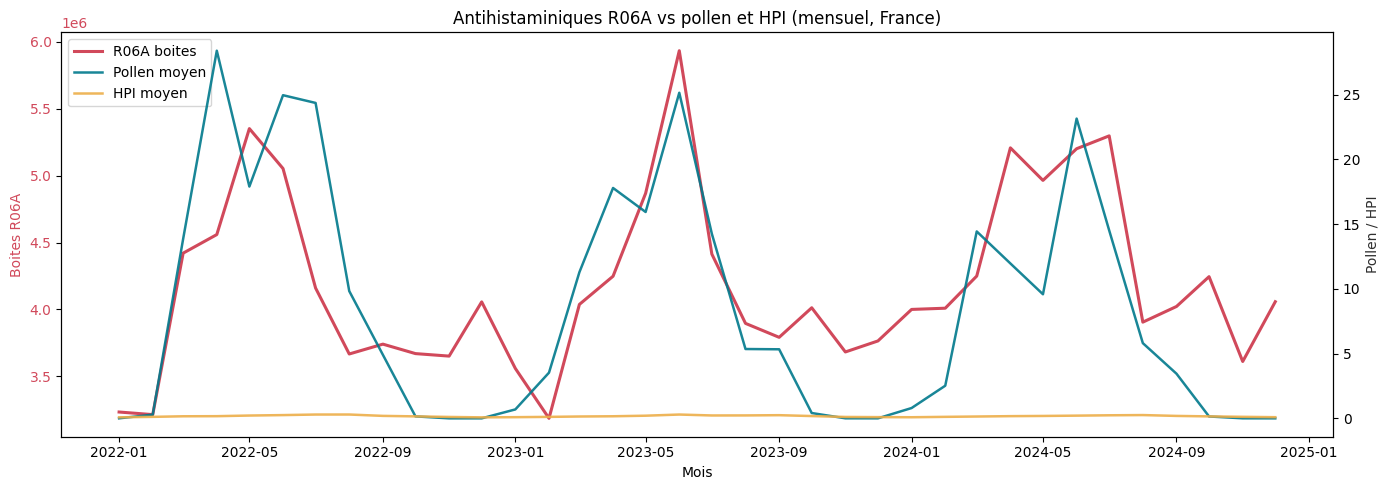

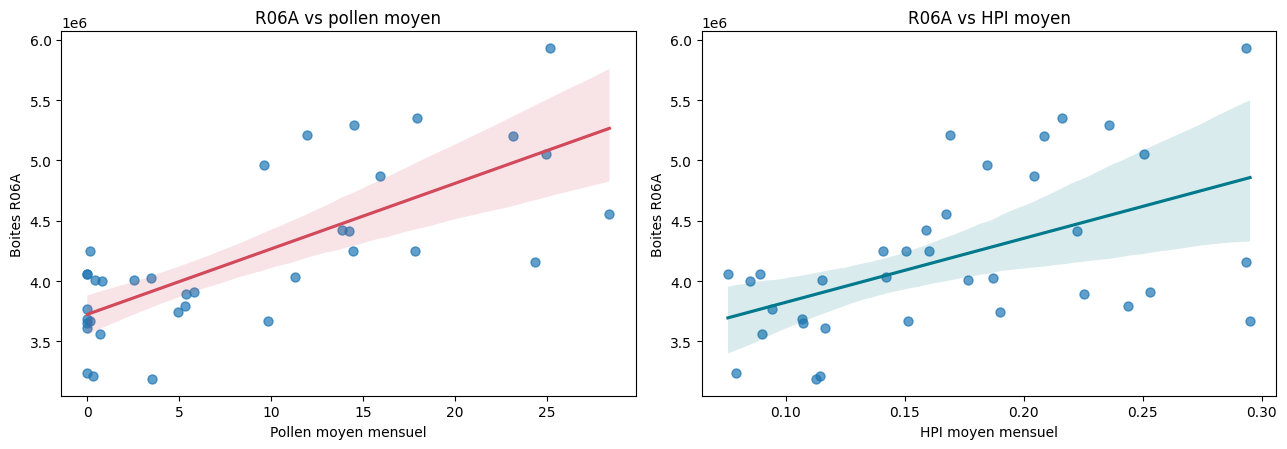

In [88]:
# Point 2 — Analyse graphique antihistaminiques vs pollen/HPI (niveau national mensuel)
import matplotlib.pyplot as plt
import seaborn as sns

if "df_atc3_all" not in locals():
    raise ValueError("df_atc3_all absent. Execute l Etape 7 avant.")

def _norm_text(x):
    s = unicodedata.normalize("NFKD", str(x)).encode("ascii", "ignore").decode("ascii")
    return re.sub(r"\s+", " ", s).strip().lower()

df_r06 = df_atc3_all.loc[df_atc3_all["code_atc3"].eq("R06A")].copy()
ind_candidates = [
    ind for ind in df_r06["indicateur"].dropna().unique().tolist()
    if ("boite" in _norm_text(ind)) and ("rembours" in _norm_text(ind))
]
if not ind_candidates:
    raise ValueError("Indicateur boites remboursées introuvable dans df_atc3_all pour R06A")
target_indicator = sorted(ind_candidates)[0]

r06_monthly_fr = (
    df_r06.loc[df_r06["indicateur"].eq(target_indicator), ["mois", "valeur"]]
    .assign(boites_r06a=lambda d: pd.to_numeric(d["valeur"], errors="coerce"))
    .groupby("mois", as_index=False)["boites_r06a"].sum()
    .dropna()
)

pollen_daily = pd.read_csv("Data/processed/pollen_weather_merged.csv", parse_dates=["date"])
hpi_daily = pd.read_csv("Data/processed/hpi_daily.csv", parse_dates=["date"])
pollen_cols = ["birch_pollen", "alder_pollen", "grass_pollen", "olive_pollen", "mugwort_pollen", "ragweed_pollen"]
pollen_daily["pollen_total"] = pollen_daily[pollen_cols].sum(axis=1, min_count=1)

daily_fr = pollen_daily[["date", "city", "pollen_total"]].merge(
    hpi_daily[["date", "city", "HPI"]],
    on=["date", "city"],
    how="inner",
)
daily_fr = daily_fr.groupby("date", as_index=False).agg(pollen_total=("pollen_total", "mean"), hpi=("HPI", "mean"))
daily_fr["mois"] = daily_fr["date"].dt.to_period("M").astype(str)
climate_monthly_fr = daily_fr.groupby("mois", as_index=False).agg(pollen_moyen=("pollen_total", "mean"), hpi_moyen=("hpi", "mean"))

analysis_fr = climate_monthly_fr.merge(r06_monthly_fr, on="mois", how="inner")
analysis_fr = analysis_fr.sort_values("mois").reset_index(drop=True)
analysis_fr["date_mois"] = pd.to_datetime(analysis_fr["mois"] + "-01")

print("Periode analysee (merge climat + R06A):", analysis_fr["mois"].min(), "a", analysis_fr["mois"].max())
display(analysis_fr.head(12))

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(analysis_fr["date_mois"], analysis_fr["boites_r06a"], color="#d1495b", linewidth=2.2, label="R06A boites")
ax1.set_ylabel("Boites R06A", color="#d1495b")
ax1.tick_params(axis="y", labelcolor="#d1495b")

ax2 = ax1.twinx()
ax2.plot(analysis_fr["date_mois"], analysis_fr["pollen_moyen"], color="#00798c", linewidth=1.8, alpha=0.9, label="Pollen moyen")
ax2.plot(analysis_fr["date_mois"], analysis_fr["hpi_moyen"], color="#edae49", linewidth=1.8, alpha=0.9, label="HPI moyen")
ax2.set_ylabel("Pollen / HPI", color="#2f2f2f")

lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")
ax1.set_title("Antihistaminiques R06A vs pollen et HPI (mensuel, France)")
ax1.set_xlabel("Mois")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
sns.regplot(data=analysis_fr, x="pollen_moyen", y="boites_r06a", ax=axes[0], scatter_kws={"alpha": 0.7, "s": 42}, line_kws={"color": "#d1495b"})
axes[0].set_title("R06A vs pollen moyen")
axes[0].set_xlabel("Pollen moyen mensuel")
axes[0].set_ylabel("Boites R06A")

sns.regplot(data=analysis_fr, x="hpi_moyen", y="boites_r06a", ax=axes[1], scatter_kws={"alpha": 0.7, "s": 42}, line_kws={"color": "#00798c"})
axes[1].set_title("R06A vs HPI moyen")
axes[1].set_xlabel("HPI moyen mensuel")
axes[1].set_ylabel("Boites R06A")
plt.tight_layout()
plt.show()


,regime_expo,n_mois,boites_moyennes,pollen_moyen,hpi_moyen
3,Pollen haut + HPI haut,4,5110935.5,22.237601,0.268290
2,Pollen haut,5,4845670.2,20.628180,0.191205
0,Autres mois,22,3936275.0,3.544998,0.128927
1,HPI haut,5,3934823.2,8.113718,0.247921


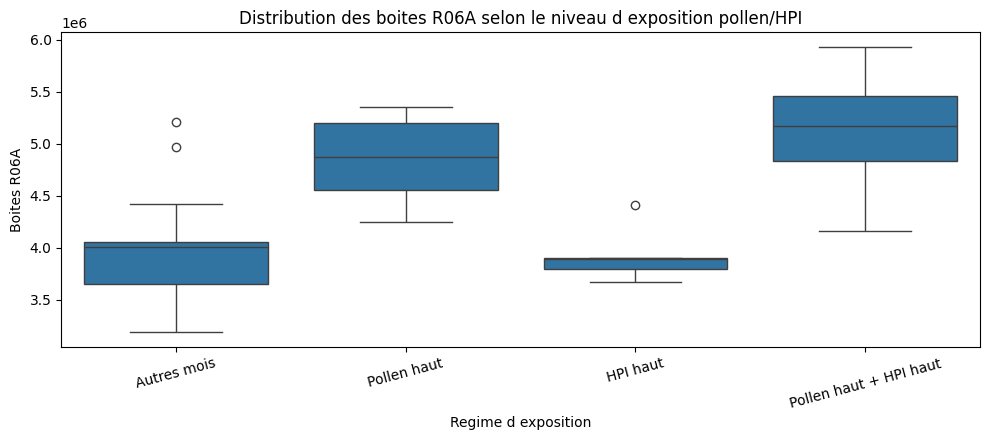

In [89]:
# Point 2 bis — Effet "haut pollen / haut HPI" sur les remboursements antihistaminiques
if "analysis_fr" not in locals():
    raise ValueError("analysis_fr absent. Execute le Point 2 avant.")

q_pollen = analysis_fr["pollen_moyen"].quantile(0.75)
q_hpi = analysis_fr["hpi_moyen"].quantile(0.75)

analysis_fr = analysis_fr.copy()
analysis_fr["pollen_haut"] = analysis_fr["pollen_moyen"] >= q_pollen
analysis_fr["hpi_haut"] = analysis_fr["hpi_moyen"] >= q_hpi
analysis_fr["regime_expo"] = "Autres mois"
analysis_fr.loc[analysis_fr["pollen_haut"], "regime_expo"] = "Pollen haut"
analysis_fr.loc[analysis_fr["hpi_haut"], "regime_expo"] = "HPI haut"
analysis_fr.loc[analysis_fr["pollen_haut"] & analysis_fr["hpi_haut"], "regime_expo"] = "Pollen haut + HPI haut"

summary_expo = (
    analysis_fr.groupby("regime_expo", as_index=False)
    .agg(
        n_mois=("mois", "count"),
        boites_moyennes=("boites_r06a", "mean"),
        pollen_moyen=("pollen_moyen", "mean"),
        hpi_moyen=("hpi_moyen", "mean"),
    )
)
display(summary_expo.sort_values("boites_moyennes", ascending=False))

order = ["Autres mois", "Pollen haut", "HPI haut", "Pollen haut + HPI haut"]
plt.figure(figsize=(10, 4.5))
sns.boxplot(data=analysis_fr, x="regime_expo", y="boites_r06a", order=order)
plt.title("Distribution des boites R06A selon le niveau d exposition pollen/HPI")
plt.xlabel("Regime d exposition")
plt.ylabel("Boites R06A")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


,annee,mois_num,boites_r06a
0,2014,1,3440642.0
1,2014,2,3359167.0
2,2014,3,3763252.0
3,2014,4,4670757.0
4,2014,5,3957429.0
5,2014,6,4467544.0
6,2014,7,4103441.0
7,2014,8,2875389.0
8,2014,9,3512254.0
9,2014,10,3588057.0


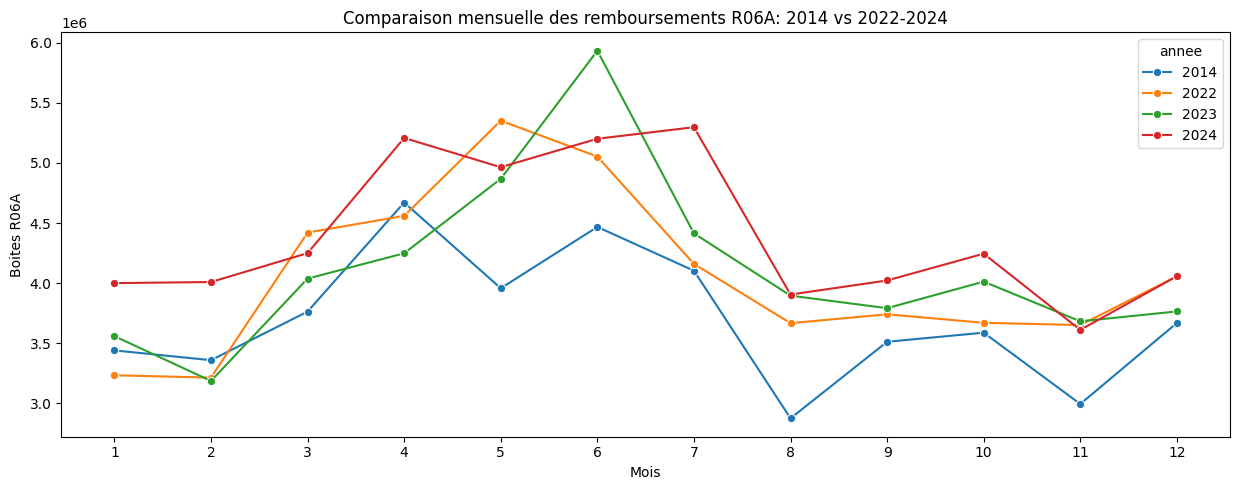

,annee,total_boites,moyenne_mensuelle
0,2014,44401256.0,3.700105e+06
1,2022,48778873.0,4.064906e+06
2,2023,49394331.0,4.116194e+06
3,2024,52771055.0,4.397588e+06


In [90]:
# Point 3 — Comparaison 2014 vs 2022-2024 (profil saisonnier antihistaminiques)
if "df_atc3_all" not in locals():
    raise ValueError("df_atc3_all absent. Execute l Etape 7 avant.")

def _norm_text2(x):
    s = unicodedata.normalize("NFKD", str(x)).encode("ascii", "ignore").decode("ascii")
    return re.sub(r"\s+", " ", s).strip().lower()

df_r06 = df_atc3_all.loc[df_atc3_all["code_atc3"].eq("R06A")].copy()
ind_candidates = [
    ind for ind in df_r06["indicateur"].dropna().unique().tolist()
    if ("boite" in _norm_text2(ind)) and ("rembours" in _norm_text2(ind))
]
target_indicator = sorted(ind_candidates)[0]

r06_monthly = (
    df_r06.loc[df_r06["indicateur"].eq(target_indicator), ["mois", "valeur"]]
    .assign(boites_r06a=lambda d: pd.to_numeric(d["valeur"], errors="coerce"))
    .groupby("mois", as_index=False)["boites_r06a"].sum()
    .dropna()
)
r06_monthly["annee"] = r06_monthly["mois"].str[:4].astype(int)
r06_monthly["mois_num"] = r06_monthly["mois"].str[-2:].astype(int)

compare_years = [2014, 2022, 2023, 2024]
r06_compare = r06_monthly.loc[r06_monthly["annee"].isin(compare_years)].copy()

season_profile = (
    r06_compare.groupby(["annee", "mois_num"], as_index=False)["boites_r06a"].mean()
)
display(season_profile.head(20))

plt.figure(figsize=(12.5, 5))
sns.lineplot(data=season_profile, x="mois_num", y="boites_r06a", hue="annee", marker="o", palette="tab10")
plt.title("Comparaison mensuelle des remboursements R06A: 2014 vs 2022-2024")
plt.xlabel("Mois")
plt.ylabel("Boites R06A")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

year_summary = (
    r06_compare.groupby("annee", as_index=False)
    .agg(total_boites=("boites_r06a", "sum"), moyenne_mensuelle=("boites_r06a", "mean"))
    .sort_values("annee")
)
display(year_summary)


## Synthèse professionnelle — Pollen, HPI et remboursements d’antihistaminiques (R06A)

### 1) Objectif
Ce notebook vise à tester si la dynamique du pollen et du **Heat-Pollution Index (HPI)** est associée aux remboursements mensuels d’antihistaminiques (`ATC3 = R06A`), puis à comparer l’apport explicatif de deux modèles :
- **Modèle A** : pollen seul  
- **Modèle B** : pollen + HPI

### 2) Données mobilisées
- **Ameli mensuel (ATC3)** : `df_atc3_all` reconstruit sur **2014–2025** (fichiers semestriels, format long).
- **Climat / exposition** : pollen et HPI quotidiens agrégés au mois (2022–2024).
- **Hospitalier** :
- `OPEN_PHMEV_2024.CSV` (exploitable pour R06A, niveau établissement/région).
- `2017-a-2025_retroced-am_serie-annuelle..xlsx` (annualisé, non contributif sur R06 dans l’état actuel).

### 3) Résultats principaux

#### 3.1 Association globale pollen / ventes R06A
- Co-saisonnalité nette : les périodes de pollen élevé coïncident avec des volumes plus élevés de boîtes R06A.
- Sur 2022–2024, l’analyse mensuelle montre un signal robuste entre pollen et remboursements.

#### 3.2 Apport du HPI (test central A vs B)
- **Modèle A (pollen)** : `R² = 0.543`
- **Modèle B (pollen + HPI)** : `R² = 0.546`
- **Gain** : `ΔR² = +0.0025`
- **F-test imbriqué** : `p = 0.671` (non significatif)

Conclusion : dans ce setup, **le HPI n’apporte pas d’amélioration statistiquement significative** au-delà du pollen seul.

#### 3.3 Analyse par ville
- Strasbourg : `ΔR² = +0.053`, `p = 0.059` (proche du seuil, non significatif)
- Paris : `ΔR² = +0.045`, `p = 0.135` (non significatif)
- Bordeaux : `ΔR² = +0.006`, `p = 0.529` (non significatif)
- Marseille : `ΔR² = +0.002`, `p = 0.706` (non significatif)

Conclusion : pas de preuve statistique solide d’un gain du modèle B par ville dans l’état actuel.

#### 3.4 Segmentation “forte exposition”
- `Pollen haut + HPI haut` : **5.11M** boîtes/mois
- `Pollen haut` : **4.85M**
- `Autres mois` : **3.94M**
- `HPI haut` seul : **3.93M**

Lecture : l’élévation est surtout portée par les mois de **pollen élevé**.

#### 3.5 Perspective temporelle 2014 vs 2022–2024
- Total annuel R06A :
- 2014 : **44.4M**
- 2022 : **48.8M**
- 2023 : **49.4M**
- 2024 : **52.8M**
- Progression 2014 → 2024 : **~+18.8%**, avec saisonnalité printanière persistante.

#### 3.6 Focus hospitalier (2024)
- `OPEN_PHMEV_2024` (R06A) :
- **81 587** lignes
- **4 042 269** boîtes
- **4 538 344** remboursés
- Région la plus contributrice : **11 (Île-de-France)** avec **1 005 359** boîtes (~25%).

### 4) Limites méthodologiques
- La cible “ville” est estimée par allocation populationnelle (pas une observation mensuelle territoriale directe).
- Le HPI peut partager une saisonnalité commune avec le pollen, limitant son gain marginal en régression linéaire simple.
- Les sources hospitalières ne sont pas alignées temporellement au même niveau de granularité que le pipeline principal mensuel.

### 5) Conclusion exécutive
- Le notebook montre une **association claire entre hausse du pollen et hausse des remboursements R06A**.
- En revanche, il ne démontre pas, à ce stade, une **valeur ajoutée statistiquement significative du HPI** par rapport au pollen seul.
- Le volet hospitalier confirme l’importance de R06A en 2024 et peut enrichir la discussion, mais pas encore renforcer une preuve causale sur la dynamique mensuelle.
